In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)


PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")

LABEL_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "july2018_regime_labels.csv"
)

MODEL_FILE = (
    PROJECT
    / "models"
    / "regime_classifier.joblib"
)

METADATA_FILE = (
    PROJECT
    / "models"
    / "regime_classifier_metadata.json"
)

PREDICTION_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "july2018_regime_cv_predictions.csv"
)

MODEL_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

In [2]:
regime_df = pd.read_csv(
    LABEL_FILE,
    parse_dates=["date"]
)

print(regime_df.shape)

display(
    regime_df[
        [
            "date",
            "prototype_regime"
        ]
    ]
)

(31, 9)


,date,prototype_regime
0,2018-07-01,Normal
1,2018-07-02,Break
2,2018-07-03,Break
3,2018-07-04,Break
4,2018-07-05,Break
5,2018-07-06,Normal
6,2018-07-07,Break
7,2018-07-08,Normal
8,2018-07-09,Normal
9,2018-07-10,Normal


In [3]:
FEATURES = [
    "central_gefs_rain",
    "regional_min_mslp",
    "regional_mean_mslp",
    "monsoon_q850",
    "monsoon_wind_speed",
    "arabian_sea_u850"
]

TARGET = "prototype_regime"


X = regime_df[FEATURES]
y = regime_df[TARGET]

print("Features:", FEATURES)
print("\nClass counts:")
print(y.value_counts())

Features: ['central_gefs_rain', 'regional_min_mslp', 'regional_mean_mslp', 'monsoon_q850', 'monsoon_wind_speed', 'arabian_sea_u850']

Class counts:
prototype_regime
Normal            11
Break              9
Low/Depression     7
Active             4
Name: count, dtype: int64


In [4]:
logistic_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        )
    )
])


forest_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])


models = {
    "Logistic Regression": logistic_model,
    "Random Forest": forest_model
}

In [5]:
cross_validation = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

model_results = {}
metric_rows = []


for model_name, model in models.items():
    predictions = cross_val_predict(
        model,
        X,
        y,
        cv=cross_validation,
        method="predict"
    )

    model_results[model_name] = predictions

    metric_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(
            y,
            predictions
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y,
                predictions
            )
        ),
        "macro_f1": f1_score(
            y,
            predictions,
            average="macro"
        )
    })


classifier_metrics_df = pd.DataFrame(
    metric_rows
).sort_values(
    "macro_f1",
    ascending=False
)

classifier_metrics_df

,model,accuracy,balanced_accuracy,macro_f1
1,Random Forest,0.548387,0.608856,0.582641
0,Logistic Regression,0.548387,0.569084,0.555660


In [6]:
best_model_name = classifier_metrics_df.iloc[0][
    "model"
]

best_model = models[
    best_model_name
]

best_cv_predictions = model_results[
    best_model_name
]

print(
    "Selected classifier:",
    best_model_name
)

Selected classifier: Random Forest


In [7]:
print(
    classification_report(
        y,
        best_cv_predictions,
        zero_division=0
    )
)

                precision    recall  f1-score   support

        Active       0.50      0.75      0.60         4
         Break       0.38      0.56      0.45         9
Low/Depression       1.00      0.86      0.92         7
        Normal       0.50      0.27      0.35        11

      accuracy                           0.55        31
     macro avg       0.60      0.61      0.58        31
  weighted avg       0.58      0.55      0.54        31



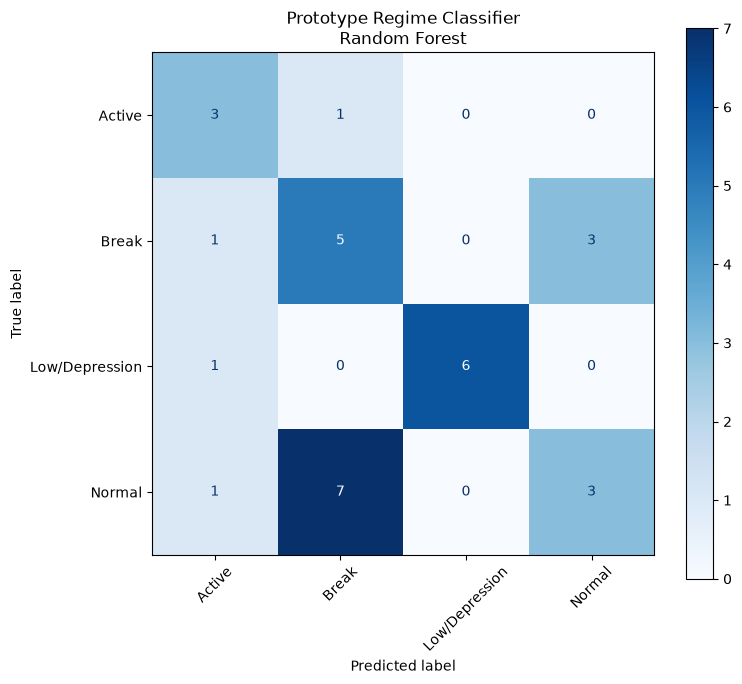

In [8]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

ConfusionMatrixDisplay.from_predictions(
    y,
    best_cv_predictions,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    f"Prototype Regime Classifier\n{best_model_name}"
)

plt.tight_layout()
plt.show()

In [9]:
output_df = regime_df[
    [
        "date",
        "prototype_regime"
    ]
].copy()

output_df["predicted_regime"] = (
    best_cv_predictions
)

output_df["correct"] = (
    output_df["prototype_regime"]
    == output_df["predicted_regime"]
)

output_df.to_csv(
    PREDICTION_FILE,
    index=False
)

display(output_df)

,date,prototype_regime,predicted_regime,correct
0,2018-07-01,Normal,Break,False
1,2018-07-02,Break,Normal,False
2,2018-07-03,Break,Break,True
3,2018-07-04,Break,Break,True
4,2018-07-05,Break,Break,True
5,2018-07-06,Normal,Break,False
6,2018-07-07,Break,Normal,False
7,2018-07-08,Normal,Normal,True
8,2018-07-09,Normal,Normal,True
9,2018-07-10,Normal,Break,False


In [10]:
best_model.fit(
    X,
    y
)

joblib.dump(
    best_model,
    MODEL_FILE
)


metadata = {
    "model_name": best_model_name,
    "features": FEATURES,
    "classes": sorted(
        y.unique().tolist()
    ),
    "training_period": (
        "2018-07-01 to 2018-07-31"
    ),
    "label_type": (
        "prototype hybrid rule-based labels"
    ),
    "limitations": (
        "Only 31 dates; not operationally validated"
    )
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        indent=2
    )


print("Model saved:", MODEL_FILE.exists())
print("Metadata saved:", METADATA_FILE.exists())

Model saved: True
Metadata saved: True


In [11]:
display(classifier_metrics_df)
print("Selected classifier:", best_model_name)

,model,accuracy,balanced_accuracy,macro_f1
1,Random Forest,0.548387,0.608856,0.582641
0,Logistic Regression,0.548387,0.569084,0.555660


Selected classifier: Random Forest
